# Prédiction de la Valorisation et de la date du prochain round avec un modèle RNN

Le Notebook ci-dessous utilise un (petit) dataset `Dataset_Entreprises_Complet_v2` et un modèle LSTM (neurones récurrents) dans l'objectif de prédire la valorisation et la date du prochain round de levée de fonds. Le Notebook se compose comme ceci:
- Nettoyage du dataset
- Standardisation du modèle (les montants sont passés en échelle logarithmique pour un meilleur entraînement)
- formatage des données/ Préparation de l'entrée en tenseurs 3D (format nécessaire pour le LSTM)
- Mise en place du LSTM avec `tensorflow`.
- Analyse des résultats (affichage des prédictions et évolution de la "loss function" (entraînement + validation)
- critique/limite du modèle et proposition d'amélioration (bais, nouvelles features etc.)

## Nettoyage des données


Avant de pouvoir réaliser un modèle (LSTM), il faut transformer le fichier brut (**issu de PitchBook**) en un format numérique, chronologique et sans aucune valeur manquante.

Le nettoyage se découpe en **6 étapes**:

### 1. Standardisation Monétaire (`clean_currency`)
Le dataset brut contient des chaînes de caractères comme `$11.8B`, `~$32M`, ou `n.d.`. 
La fonction `clean_currency`:
* supprime les symboles parasites (`$`, `~`, `,`).
* convertit tout en **Million de dollars**.
* Elle convertit les textes de données manquantes en (`nan`).
  
### 2. Renommage
On renomme les colonnes de PitchBook (`Amount`, `Post-Val`, `Raised to Date`, `Company`) en variables standards (`Amount_Raised_M`, `Post_Val_M`, `Total_Raised_to_Date_M`, `Company_ID`).

### 3. Application du Nettoyage Financier
Application de `clean_currency` sur  les colonnes argents.

### 4. Formatage temporel

* Transformation des dates textuelles (`May-22`) en objets `DateTime`.
* Tri du tableau par `Company_ID`, puis par date **croissante**.

### 5. Nouvelles Features
Le temps qui s'écoule entre les rounds est une donnée fondamentale. On crée deux nouvelles variables :

* `Months_Since_Last_Round` : La durée en mois depuis la précédente levée. (Vaut 0 pour la toute première levée).
* `Round_Date_YearFloat` : Représentation décimale de la date (ex: `2022.5` pour Juin 2022): permet au modèle de comprendre le contexte macro-économique (ex: le boom de 2021 vs la crise de 2023).

### 6. Filtre Anti-NaN 
Puisque le LSTM analyse des séquences *complètes*, on ne peut pas garder de rounds "à trous". 
On supprime donc toute ligne qui n'a pas ses 5 variables descriptives (`feature_cols`) complètes et valides.

In [1]:
import pandas as pd
import numpy as np

def clean_currency(x):
    if pd.isna(x) or str(x).strip().lower() in ['n.d.', 'nan', 'n/a', 'none', '']:
        return np.nan
    val_str = str(x).replace('$', '').replace('~', '').replace(',', '').strip()
    try:
        if 'B' in val_str:
            return float(val_str.replace('B', '')) * 1000
        elif 'M' in val_str:
            return float(val_str.replace('M', ''))
        elif 'K' in val_str:
            return float(val_str.replace('K', '')) / 1000
        else:
            return float(val_str)
    except:
        return np.nan

# 1. Chargement des données
df_raw = pd.read_csv('Dataset_Entreprises_Complet_v2.csv')
df_clean = df_raw.copy()

# 2. RENOMMAGE DES COLONNES
df_clean = df_clean.rename(columns={
    'Post-Val': 'Post_Val_M',
    'Amount': 'Amount_Raised_M',
    'Raised to Date': 'Total_Raised_to_Date_M',
    'Company': 'Company_ID'
})

# 3. Nettoyage financier
colonnes_financieres = ['Amount_Raised_M', 'Total_Raised_to_Date_M', 'Pre-Val', 'Post_Val_M']
for col in colonnes_financieres:
    df_clean[col] = df_clean[col].apply(clean_currency)

# 4. Traitement des Dates 
df_clean['Date_Parsed'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# --- TRI CHRONOLOGIQUE ---
# On trie uniquement par Entreprise puis par Date croissante
df_clean = df_clean.sort_values(by=['Company_ID', 'Date_Parsed'], ascending=[True, True])

# 5. Calcul des variables temporelles
df_clean['Months_Since_Last_Round'] = df_clean.groupby('Company_ID')['Date_Parsed'].diff().dt.days / 30.44
df_clean['Months_Since_Last_Round'] = df_clean['Months_Since_Last_Round'].fillna(0)

df_clean['Round_Date_YearFloat'] = df_clean['Date_Parsed'].dt.year + (df_clean['Date_Parsed'].dt.month / 12.0)

# 6. Filtrage

feature_cols = ['Post_Val_M', 'Round_Date_YearFloat', 'Months_Since_Last_Round', 'Amount_Raised_M', 'Total_Raised_to_Date_M']
df_clean = df_clean.dropna(subset=feature_cols + ['Date_Parsed'])

print("Nettoyage terminé !")
print(f"Il reste {len(df_clean)} rounds exploitables.")
feature_cols = ['Post_Val_M', 'Round_Date_YearFloat', 'Months_Since_Last_Round', 'Amount_Raised_M', 'Total_Raised_to_Date_M']
print(df_clean[['Company_ID', 'Date_Parsed'] + feature_cols].head(10))

Nettoyage terminé !
Il reste 1996 rounds exploitables.
      Company_ID Date_Parsed  Post_Val_M  Round_Date_YearFloat  \
1217    4D Sight  2020-01-01        0.50           2020.083333   
1218    4D Sight  2020-03-15        0.52           2020.250000   
1216    4D Sight  2021-11-07       52.17           2021.916667   
1215    4D Sight  2022-08-31       65.00           2022.666667   
175       6Sense  2013-01-01     1100.00           2013.083333   
174       6Sense  2014-01-01       10.00           2014.083333   
1373  ADVANCE.AI  2015-06-01       50.80           2015.500000   
1372  ADVANCE.AI  2016-01-01       71.50           2016.083333   
1371  ADVANCE.AI  2018-07-18      310.90           2018.583333   
1370  ADVANCE.AI  2019-09-20      617.30           2019.750000   

      Months_Since_Last_Round  Amount_Raised_M  Total_Raised_to_Date_M  
1217                 0.000000            0.075                    0.33  
1218                 2.431012            0.330                    0.33  

/tmp/ipykernel_1247995/869288822.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['Date_Parsed'] = pd.to_datetime(df_clean['Date'], errors='coerce')


## Standardisation du modèle



### 1. Copie
`df_scaled = df.copy()`
On travaille sur une copie du dataset propre pour ne pas altérer les données d'origine en cas d'erreur.

### 2. La Transformation Logarithmique
`np.log1p()` ($log(x + 1)$) est appliqué sur toutes les colonnes financières. 
* **Intérêt :** quelques "Licornes" valent des milliards, la majorité vaut quelques millions. Si on standardise directement, les petites startups se retrouvent écrasées ( = perte d'information pour l'apprentissage).
Le logarithme compresse les valeurs extrêmes.

### 3. Double Scaler
Création de deux objets `StandardScaler` distincts : `scaler_features` et `scaler_target`.
* Le `scaler_features` va transformer toutes les variables d'entrée.
* Le `scaler_target` (**scaler de sauvegarde**).On l'entraine uniquement sur les deux variables à prédire (Valorisation et Temps). Permet de faire l'opération inverse (`inverse_transform`) pour avoir les prédictions en vrais "Millions de dollars" et "Mois".

### 4. L'Ordre des opérations
L'ordre est important  :
1. **D'abord**, on applique le Logarithme.
2. **Ensuite**, on entraîne le `scaler_target` (`.fit()`). Il mémorise ainsi l'échelle logarithmique.  
3. **Enfin**, on applique la Standardisation (`fit_transform`) sur tout le tableau (centre toutes les données sur 0 avec un écart-type de 1)


In [2]:
from sklearn.preprocessing import StandardScaler
def standardiser_donnee(df):

    df_scaled = df.copy()
    
    colonnes_a_standardiser = [
        'Post_Val_M',
        'Round_Date_YearFloat',
        'Months_Since_Last_Round', 
        'Amount_Raised_M', 
        'Total_Raised_to_Date_M'
    
    ]

    colonnes_cibles = ['Post_Val_M', 'Months_Since_Last_Round']
    
# On transforme les dollars en logarithme pour stabiliser le réseau
    for col in ['Post_Val_M', 'Amount_Raised_M', 'Total_Raised_to_Date_M']:
        df_scaled[col] = np.log1p(df_scaled[col])
        
    # On garde un scaler SPÉCIFIQUE pour la cible (Post_Val_M) pour pouvoir
    # retransformer la prédiction en vrais millions
    scaler_features = StandardScaler() #instansification
    scaler_target = StandardScaler()

    # On entraîne le scaler de la cible SUR LES LOGARITHMES 
    scaler_target.fit(df_scaled[colonnes_cibles]) 

    # ENSUITE, on standardise tout le tableau
    df_scaled[colonnes_a_standardiser] = scaler_features.fit_transform(df_scaled[colonnes_a_standardiser])

    return df_scaled, scaler_target

## Préparation des données d'entrée et de sortie 

Les réseaux de neurones récurrents (comme le LSTM) exigent une structure de données en **3 dimensions** (Tenseur). 

L'objectif de cette fonction est de transformer l'historique de startups en blocs de données de format `[Échantillons, Étapes Temporelles, Variables]`.

Les étapes du code sont : 

### 1. Groupement et Filtrage
Le code regroupe toutes les lignes appartenant à la même startup. 
* **Condition :** Si une startup n'a fait qu'une seule levée de fonds, elle est ignorée (`if n_rounds < 2: continue`). Sans historique, Le modèle ne va pas apprendre

### 2. Séparation du Passé (X) et du Futur (y)
Pour chaque startup valide, on coupe l'historique en deux :
* **L'historique (`X_hist`) :** features (`features_cols`) de tous les rounds d'une même startup **sauf le tout dernier (échantillon d'entrée)**

* **La Cible (`y_cible`) :** Le tout dernier round (valorisation et temps écoulé).

### 3. Le Padding
Il est nécessaire que les paramètres d'entrée soient **de même taille**. 
Mais les startups n'ont pas toutes le même nombre de rounds.
* On définit une taille standard maximale (`MAX_ROUNDS`).
* On crée une matrice vide de cette taille, remplie de **`-99.0`**.
* On insère le véritable historique de la startup dans cette matrice.
* **choix de -99.0 :** Les vraies données ont été standardisées (autour de 0). Le modèle LSTM utilisé ne doit pas apprendre sur des rounds qui n'existent pas. Le LSTM dispose d'une fonction de masque (via une couche `Masking`) qui va lui permettre d'ignorer les cases qui ont une valeur -99,0. Cette valeur est arbitraire et permet de ne pas compromettre les données utiles standardisées.

### 4. Le Résultat Final (Les Tenseurs)
Le code compile toutes ces matrices pour créer nos variables d'entraînement finales :
* **X (L'entrée) :** Un bloc 3D dont les dimensions sont `[Nombre d'entreprises, MAX_ROUNDS, 5 features]`.
* **y (La sortie) :** Un tableau 2D contenant nos réponses `[Valorisation à deviner, Mois à deviner]`.
* **Noms :** Une liste contenant les noms des startups.

In [3]:
def creer_tenseurs_3d(df_scaled, max_rounds):
    
    feature_cols = [
        'Post_Val_M',                # Valorisations (historiques) 
        'Round_Date_YearFloat',      # Date du round
        'Months_Since_Last_Round',   # Nombre de mois entre les rounds
        'Amount_Raised_M',           # Le montant levé
        'Total_Raised_to_Date_M'     # Le montant total levé
    ]

    MAX_ROUNDS = max_rounds # Nombre de rounds maximal  présent dans le csv (ligne) # IMPORTANT 
    NUM_FEATURES = len(feature_cols) # Nombre de features de l'entreprise (colonne)

    X_list = [] #entrée
    y_list = [] #sortie
    noms_list = [] #nom des startups

    # On groupe par boîte
    grouped = df_scaled.groupby("Company_ID")

    for Company_id, group in grouped[feature_cols]: #(clé, valeur)
    
        n_rounds = len(group) #nombre de rounds de l'entreprise
    
        # Si la startup n'a fait qu'une seule levée, on ne peut pas l'utiliser 
        # car il nous faut au moins 1 round historique pour prédire le 2ème.
        if n_rounds < 2:
            continue
    
        company_data = group[feature_cols].values # array des features à chaque round (ligne = round), (colonne = features)
        X_hist = company_data[:-1] # on enlève le dernier round
        y_cible = company_data[-1,[0,2]] # la valorisation du dernier round (1ere colonne) et month_since_last_round (3eme colonne)
    
        # --- LE PADDING --- (comblet les rounds inexistants (peut être futur) par des valeurs qui ne vont pas interférer avec le reste)
      # On utilise -99.0 pour combler les rounds inexistants
        X_padded = np.full((MAX_ROUNDS, NUM_FEATURES), -99.0)
        # On insère l'historique dans cette matrice.
        # Ex: Si la startup a 3 rounds historiques, ça remplit les 3 premières lignes, le reste reste à -99.
    
        history_length = len(X_hist)
        X_padded[:history_length, :] = X_hist #Attention, si une entreprise a plus de MAX_ROUNDS ça ne marche pas !!!
    
        # On ajoute tout
        X_list.append(X_padded)
        y_list.append(y_cible)
        noms_list.append(Company_id)

    # Conversion en tenseurs 3D (format pour TensorFlow/Keras)
    X = np.array(X_list)
    y = np.array(y_list)

    print(f"Dimensions de l'échantillon d'entrée (X) : {X.shape}")
    print(f"Ce qui signifie : {X.shape[0]} entreprises, {X.shape[1]} étapes max, {X.shape[2]} variables.")
    print(f"Dimensions des cibles (y) : {y.shape}")
    return X, y, np.array(noms_list)

## Construction et Entraînement du Réseau de Neurones (LSTM)

Ce bloc de code prend nos données préparées, construit l'architecture du modèle (les couches de neurones), et lance la phase d'apprentissage.

Voici l'agencement du programme :

### 1. Préparation Finale et Séparation (Train / Test)
* Le code calcule automatiquement le nombre maximum de rounds historiques (`max_rounds`) présent dans les données pour adapter la taille des matrices (profondeur).
* **Tenseurs 3D :** Les données sont empilées dans des blocs tridimensionnels `(Entreprises, Rounds, Variables)` que le LSTM peut lire.
* **Split 80/20 :** Les startups sont mélangées aléatoirement et divisées. 80% serviront à l'entraînement, et 20% seront gardées pour le test final.
  
### 2. L'Architecture du Modèle (Les Couches Séquentielles)
Le modèle est construit comme une chaîne (`Sequential`) où la donnée traverse 4 filtres successifs :
* **La Couche `Masking` (Le Filtre d'entrée) :** Puisque nous avons comblé le vide des historiques courts avec des `-99.0` (padding), cette couche permet au modèle de les ignorer.
  
* **La Couche `LSTM` (La Mémoire Temporelle) :** C'est le cœur de l'analyse. Ses `32` neurones lisent le passé financier round par round et se transmettent le contexte. `return_sequences=False` signifie que le LSTM ne rend son verdict qu'à la toute fin de sa lecture de l'historique, après avoir synthétisé toute la trajectoire de la startup.

  
* **La Couche `Dropout` (Evite le surapprentissage) :** Elle éteint aléatoirement 20% (`0.2`) des connexions neuronales à chaque étape d'entraînement. Cela force le réseau à comprendre la logique financière globale plutôt que d'apprendre le dataset par cœur (**Les résultats sont expérimentalement nettement supérieurs avec le dropout**).

* **La Couche `Dense` (La Décision Finale) :** C'est la sortie du réseau. Elle compte `2` neurones (on lui demande de prédire 2 choses distinctes). Son activation est `linear` (linéaire) car on réalise de la *régression* : on veut prédire la Valorisation et le Temps en mois.

### 3. Compilation
On définit ici les instructions d'évaluation :
* **L'Optimiseur (`Adam`) :** C'est l'algorithme qui va ajuster les neurones. Sa vitesse d'apprentissage (`learning_rate=0.001`) définit la taille de ses pas.
  
* **La Fonction de Perte (`MSE` - Mean Squared Error) :** score que la machine cherche à minimiser

* **La Métrique (`MAE` - Mean Absolute Error) :** valeur affichée (facilement interprétable).

### 4. L'Entraînement (`model.fit`)
On donne ces hyperparamètres : 
* **`epochs=100`**
* **`batch_size=64` :** Le modèle étudie des paquets ("batchs") de 64 entreprises, fait une moyenne de ses erreurs sur ces 64 exemples, puis met à jour ces poids.

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

#formatage des données
df_standardise, scaler_target = standardiser_donnee(df_clean)
max_rounds = df_clean.groupby('Company_ID').size().max() # ROUND MAXIMAL DANS LE MODELE
X, y, noms = creer_tenseurs_3d(df_standardise, max_rounds)

# Séparation des données en jeu d'Entraînement (80%) et de Test (20%)
X_train, X_test, y_train, y_test, noms_train, noms_test = train_test_split(
    X, y, noms, test_size=0.2, random_state=42
)

# Définition de l'architecture du RNN (LSTM)

model = Sequential([
    # LA COUCHE DE MASKING : On dit au LSTM d'ignorer les lignes de 0.0 dans la donnée d'une entreprise
    # input_shape=(15, 5) -> 15 rounds maximum, 5 variables explicatives
    Masking(mask_value=-99.0, input_shape=(X.shape[1], X.shape[2])),
    
    # COUCHE LSTM (Analyse) : gère la mémoire d'un round à l'autre.
    # units=32 : Case mémoire du LSTM (neurones LSTM), activation usuelle (tanh)
    # return_sequences=False : On veut uniquement la mémoire finale à la fin de l'historique,
    # pas une prédiction à chaque round intermédiaire.
    LSTM(units=32, activation='tanh', return_sequences=False),
    # On éteint aléatoirement 20% des signaux sortant du LSTM pendant l'entraînement
    Dropout(0.2),
    # COUCHE DE SORTIE : 1 seul neurone avec une activation linéaire pour faire de la régression
    # (prédire un chiffre : la valo).
    # le LSTM donne 32 valeurs abstraites (units), un neurone renvoie la valo à partir du LSTM l'autre la durée demandée
    Dense(units=2, activation='linear')
])

# Compilation du modèle

# Le moteur (optimizer) 'adam' ajuste les poids, et la fonction de perte 'mse' (Mean Squared Error)
# mesure l'écart au carré entre la vraie valorisation standardisée et la prédiction.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'] # Mean Absolute Error : erreur moyenne absolue pour suivre la performance
)

# Affichage du résumé de l'architecture
model.summary()

# Entraînement
print("\nLancement de l'entraînement...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,         # Nombre de passages complets sur le dataset
    batch_size=64,     # Le modèle analyse 32 startups avant de mettre à jour sa mémoire globale
    verbose=1
)


I0000 00:00:1783070170.767603 1247995 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Dimensions de l'échantillon d'entrée (X) : (291, 29, 5)
Ce qui signifie : 291 entreprises, 29 étapes max, 5 variables.
Dimensions des cibles (y) : (291, 2)


/home/jupyter-ndemore/.local/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1783070174.542223 1248602 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783070174.599802 1248602 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783070174.802267 1247995 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 29, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,930 (19.26 KB)

 Trainable params: 4,930 (19.26 KB)

 Non-trainable params: 0 (0.00 B)


Lancement de l'entraînement...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - loss: 1.0468 - mae: 0.8036 - val_loss: 1.3373 - val_mae: 0.8058
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 1.0306 - mae: 0.7943 - val_loss: 1.2879 - val_mae: 0.7837
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.9565 - mae: 0.7544 - val_loss: 1.2447 - val_mae: 0.7657
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.9199 - mae: 0.7306 - val_loss: 1.2070 - val_mae: 0.7494
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.8747 - mae: 0.7057 - val_loss: 1.1762 - val_mae: 0.7357
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.8397 - mae: 0.6876 - val_loss: 1.1497 - val_mae: 0.7246
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.8185 - mae: 0.6728 - val_loss: 1.1283 - val_mae: 0.7185
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.7977 - mae: 0.6570 - val_loss: 1.1105 - val_mae: 0.7151
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0

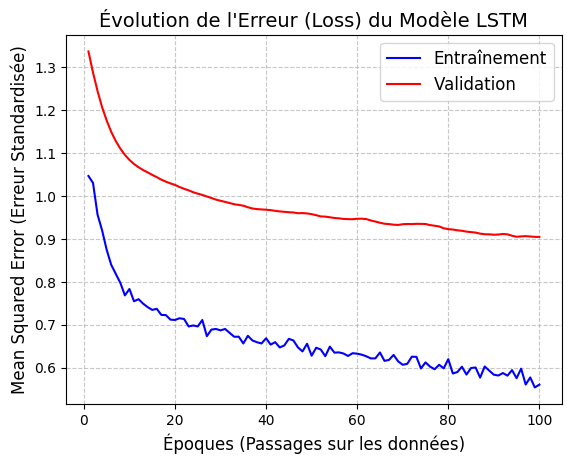

In [11]:
## Analyse des résultats

import matplotlib.pyplot as plt

# 1. Récupération des données de Loss (MSE)
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# 2. Création du graphique

plt.plot(epochs, train_loss, 'b-', label='Entraînement')
plt.plot(epochs, val_loss, 'r-', label='Validation ')

plt.title('Évolution de l\'Erreur (Loss) du Modèle LSTM', fontsize=14)
plt.xlabel('Époques (Passages sur les données)', fontsize=12)
plt.ylabel('Mean Squared Error (Erreur Standardisée)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Test de prédiction

Calcul des prédictions en cours...

 Génération des graphiques pour 10 startups...



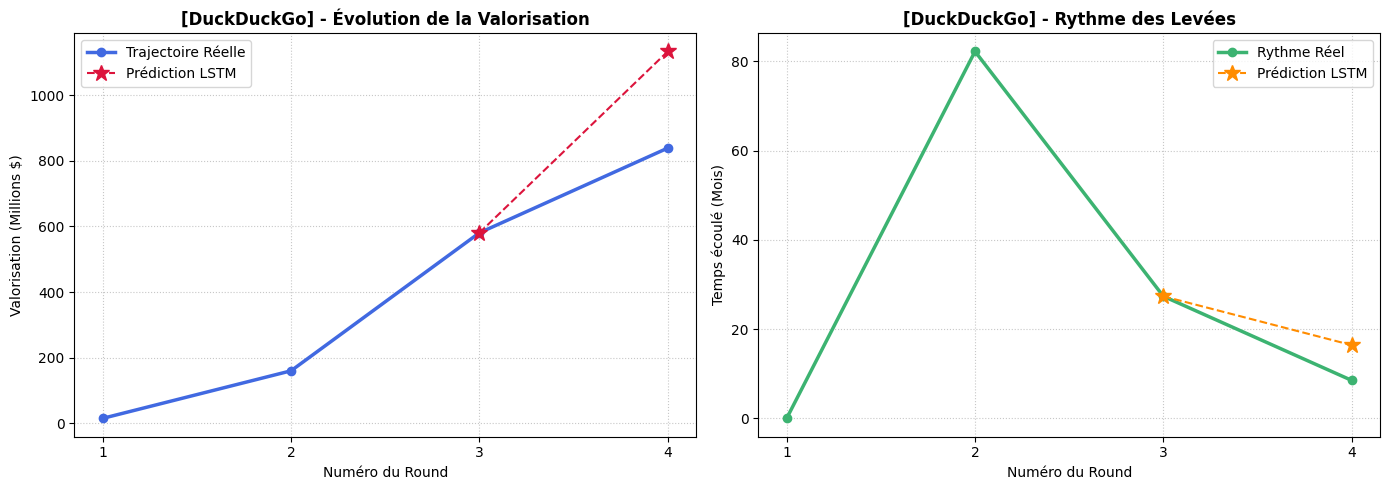

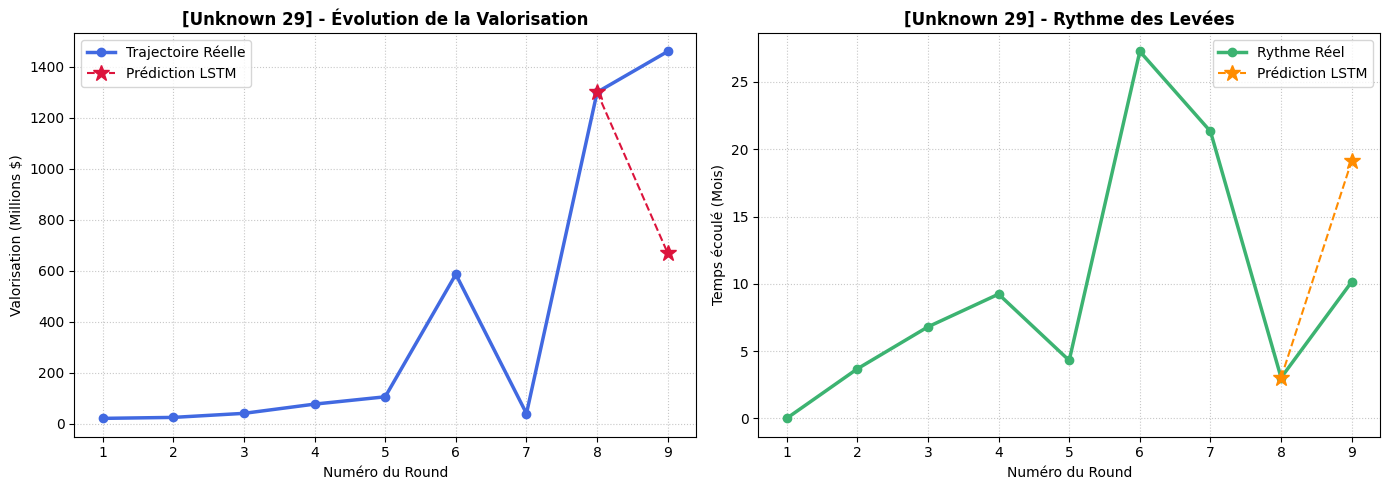

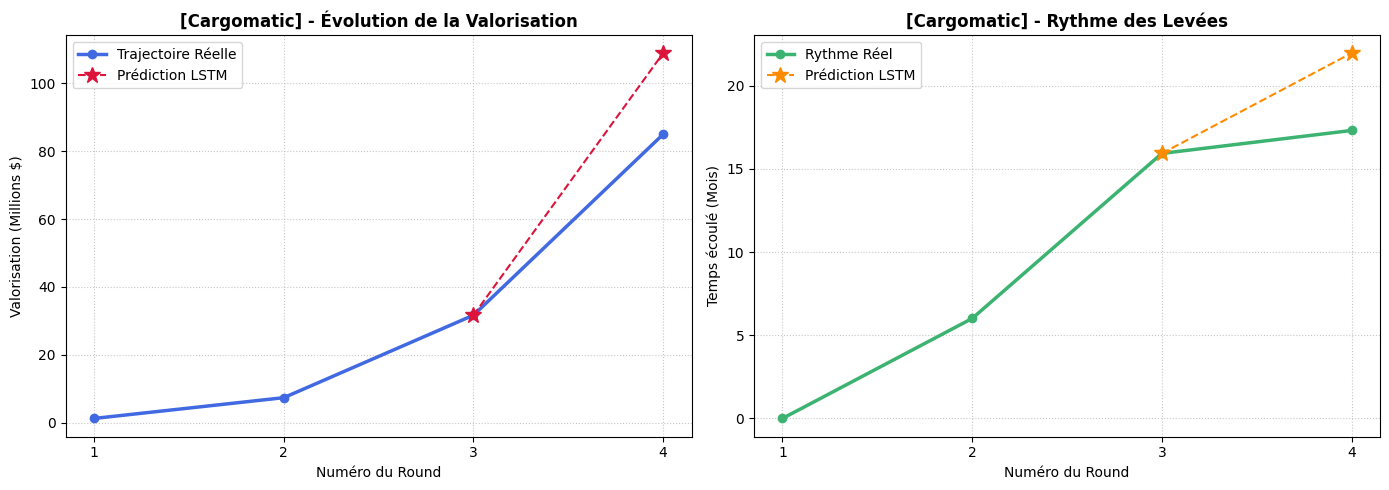

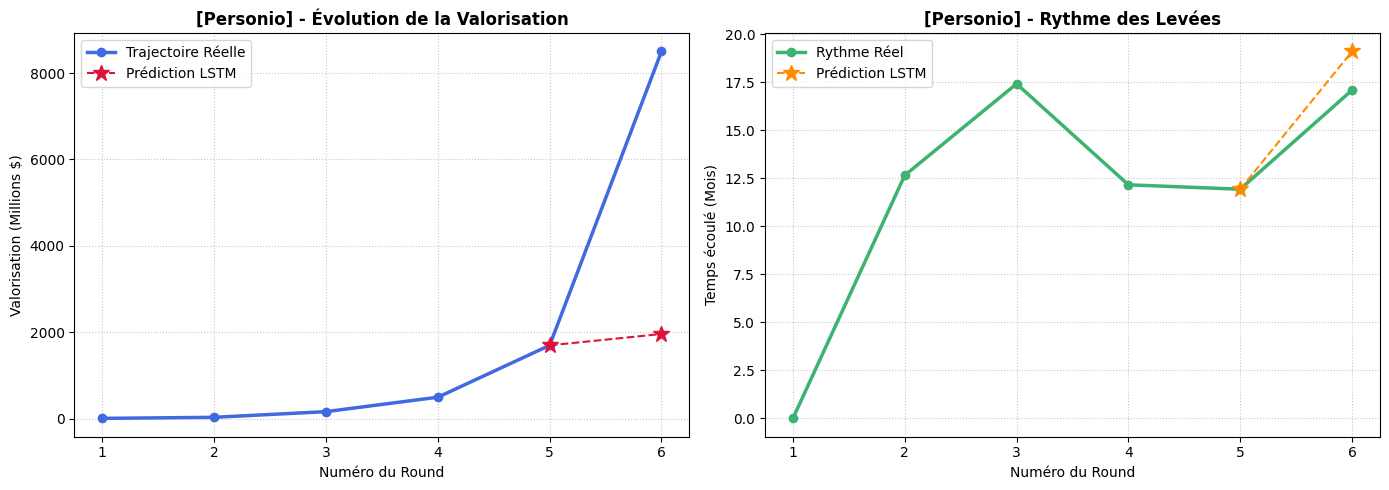

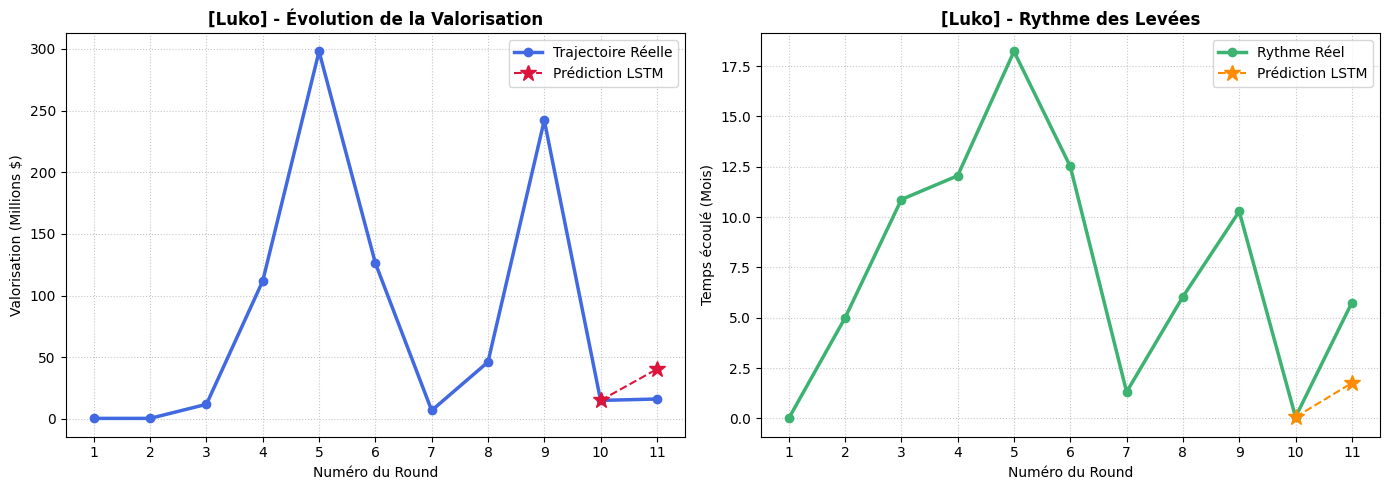

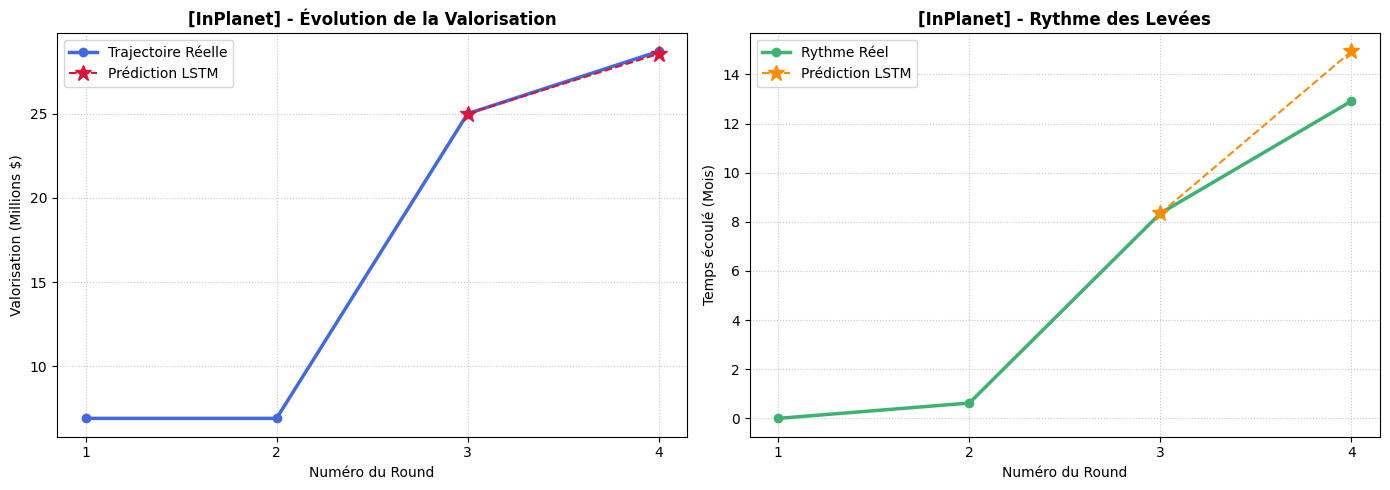

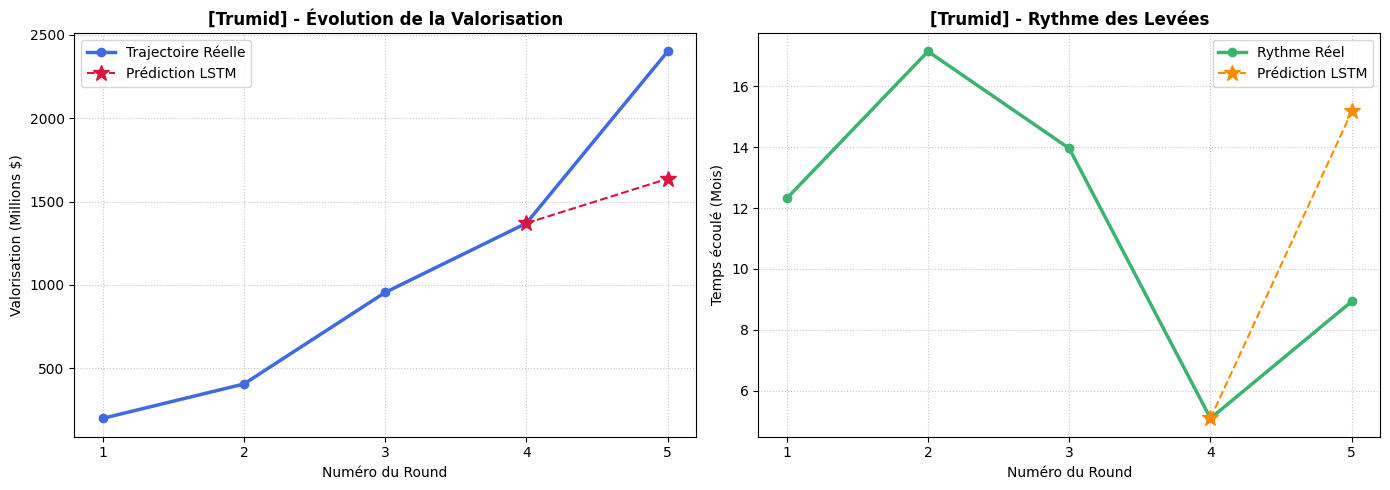

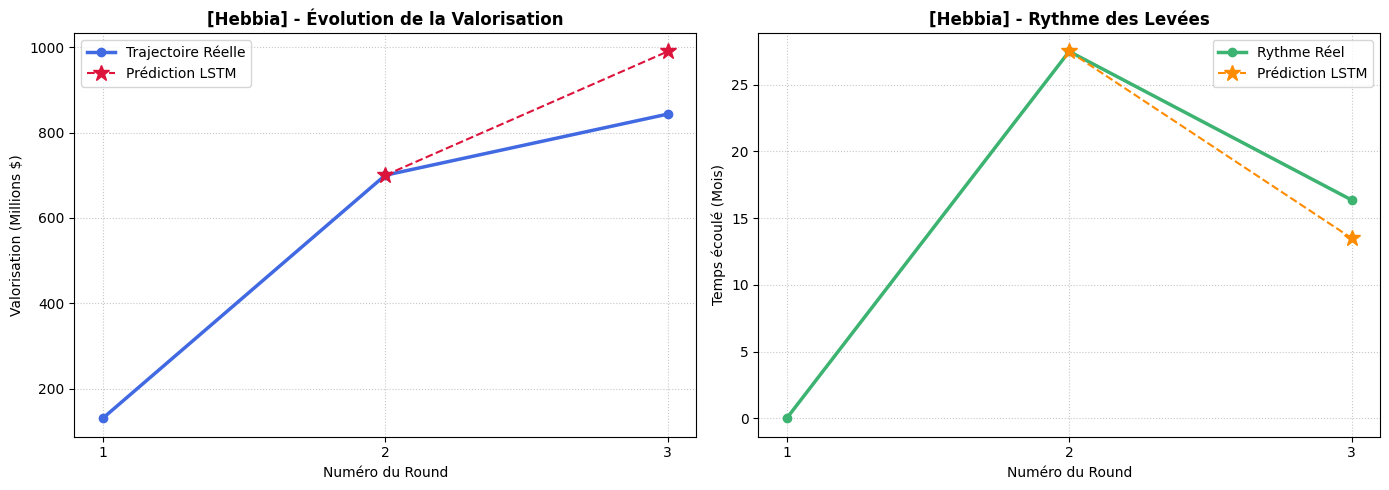

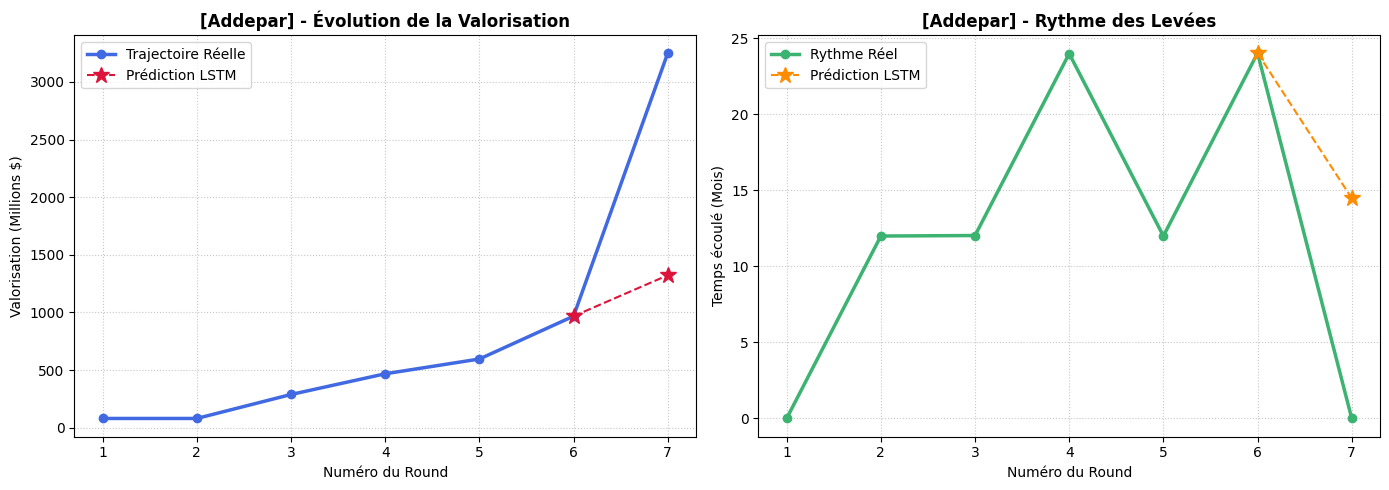

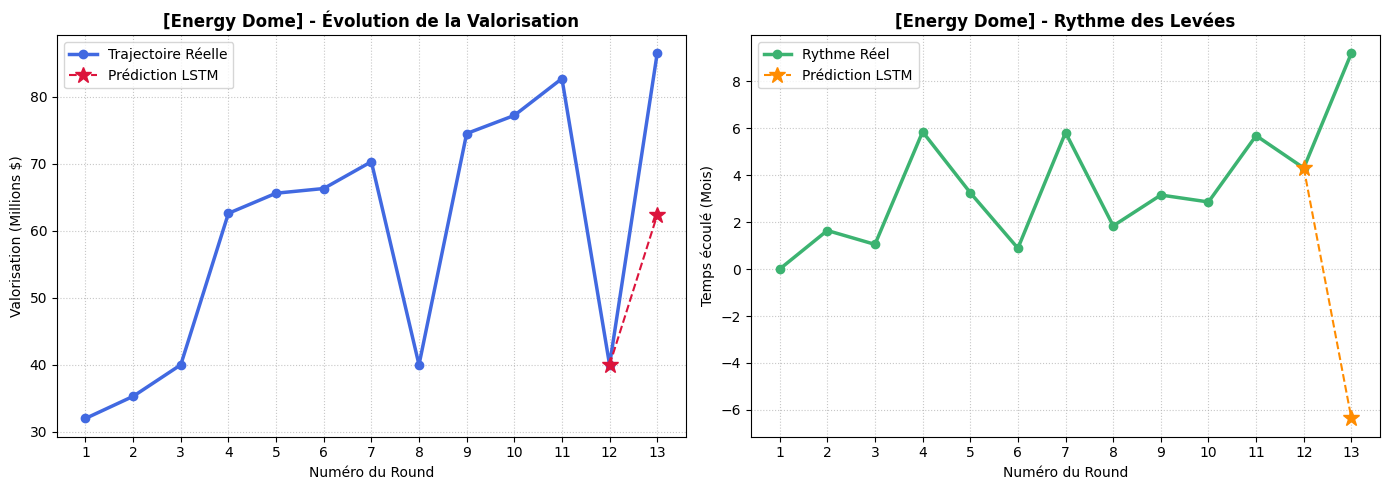

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CALCUL DES PRÉDICTIONS EN ARRIÈRE-PLAN
# ==========================================
print("Calcul des prédictions en cours...")
predictions_standard = model.predict(X_test, verbose=0)

# On annule la standardisation et le logarithme
predictions_log = scaler_target.inverse_transform(predictions_standard)
valo_predite_M = np.expm1(predictions_log[:, 0]) # Exponentielle sur la valo
mois_predits = predictions_log[:, 1]             # Les mois restent tels quels

# ==========================================
# GÉNÉRATION DES GRAPHIQUES
# ==========================================
nb_startups_a_tracer = 10
print(f"\n Génération des graphiques pour {nb_startups_a_tracer} startups...\n")

for i in range(min(nb_startups_a_tracer, len(noms_test))):
    startup = noms_test[i]
    
    # Récupération de l'historique chronologique parfait depuis df_clean
    historique_reel = df_clean[df_clean['Company_ID'] == startup]
    
    valos_reelles = historique_reel['Post_Val_M'].values
    mois_reels = historique_reel['Months_Since_Last_Round'].values
    rounds = np.arange(1, len(valos_reelles) + 1)
    
    # prédictions pour le dernier round
    pred_valo = valo_predite_M[i]
    pred_mois = mois_predits[i]
    
    # Préparation de la figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- GRAPHIQUE 1 : TRAJECTOIRE DE LA VALORISATION ---
    
    # Vraie trajectoire en bleu
    ax1.plot(rounds, valos_reelles, marker='o', color='royalblue', label='Trajectoire Réelle', linewidth=2.5)
    # Prédiction en pointillé rouge
    ax1.plot([rounds[-2], rounds[-1]], [valos_reelles[-2], pred_valo], 
             marker='*', color='crimson', linestyle='--', markersize=12, label='Prédiction LSTM')
    
    ax1.set_title(f"[{startup}] - Évolution de la Valorisation", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Numéro du Round", fontsize=10)
    ax1.set_ylabel("Valorisation (Millions $)", fontsize=10)
    ax1.set_xticks(rounds)
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()

    # --- GRAPHIQUE 2 : TRAJECTOIRE DU TIMING (MOIS) ---
    
    # Vrai rythme en vert
    ax2.plot(rounds, mois_reels, marker='o', color='mediumseagreen', label='Rythme Réel', linewidth=2.5)
    # Prédiction en pointillé orange
    ax2.plot([rounds[-2], rounds[-1]], [mois_reels[-2], pred_mois], 
             marker='*', color='darkorange', linestyle='--', markersize=12, label='Prédiction LSTM')
    
    ax2.set_title(f"[{startup}] - Rythme des Levées", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Numéro du Round", fontsize=10)
    ax2.set_ylabel("Temps écoulé (Mois)", fontsize=10)
    ax2.set_xticks(rounds)
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend()
    plt.tight_layout()
    plt.show()

## Pistes d'amélioration (à mettre en place)

### "Simplicité" du modèle

Le LSTM et le principe du réseau de neurones récurrents semblent être adaptés à la prédiction de la valorisation puisque ce dernier permet d'introduire une notion d'évolution temporelle (Rounds) que le NN classique ou le "random forest" ne saurait interpréter. 
Bien que les courbes "loss" montrent que le LSTM apprend une certaine dynamique, la prédiction sur certaines startups est très erronée ; cela s'explique par le peu de données sur lesquelles le modèle s'entraîne (peu d'entreprises et peu de features exploitables). Le fait que la prédiction ne soit, malgré tout, pas aléatoire montre que le LSTM peut être un bon moyen solide de prédiction à condition qu'il soit entraîné sur des datasets beaucoup plus complets.

### Problème du Dilemme du survivant
Attention, peut-être que l'entraînement sur le Dataset (aussi vrai soit-il) crée un **biais de type dilemme du survivant**. Par exemple, si une startup ne réalise pas de round suivant, c'est peut-être parce qu'elle a fait faillite et n'est plus dans l'attente d'un round. Le LSTM n'a pas accès à cette donnée, ce qui pourrait créer un biais. Il serait intéressant de récupérer cette donnée pour la retranscrire sous forme d'un **booléen** (1 si elle est toujours en course; 0 sinon) que le modèle pourrait capter.


On propose ici quelques features simples à mettre en place :
### Nouvelles features :
- nombre d'investisseurs à chaque round, nombre d'investisseurs top tier (nécessite que le nom des investisseurs soient présent à **chaque round**); simple à standardiser
- secteur d'activité de chaque startup (One-hot encoding)
- le "stage" de la boîte (One-hot encoding)
- le pays (One-hot encoding)
- l'efficience du marché ("Total_raised_to_date/Post_Val")
- Multiple de croissance (Post_Val/Pre_post_Val)
- les données macros :taux d'intérêt de la banque centrale le mois de la levée;
  l'indice NASDAQ à la date de clôture (valo publique se répercutent sur les valo privées)
  